# Crear el dominio del glaciar 

En este cuaderno aprenderemos a crear el dominio del glaciar. Usaremos los netcdf creados previamente. 

## Importar librerias **`Xarray`** y **`Numpy`** 

Domínio criado e salvo em: /home/matheus/Documentos/GitHub/LACRIO/Analises/Dominio/dados/dominios/Quilcayhuanca_dominio.tif


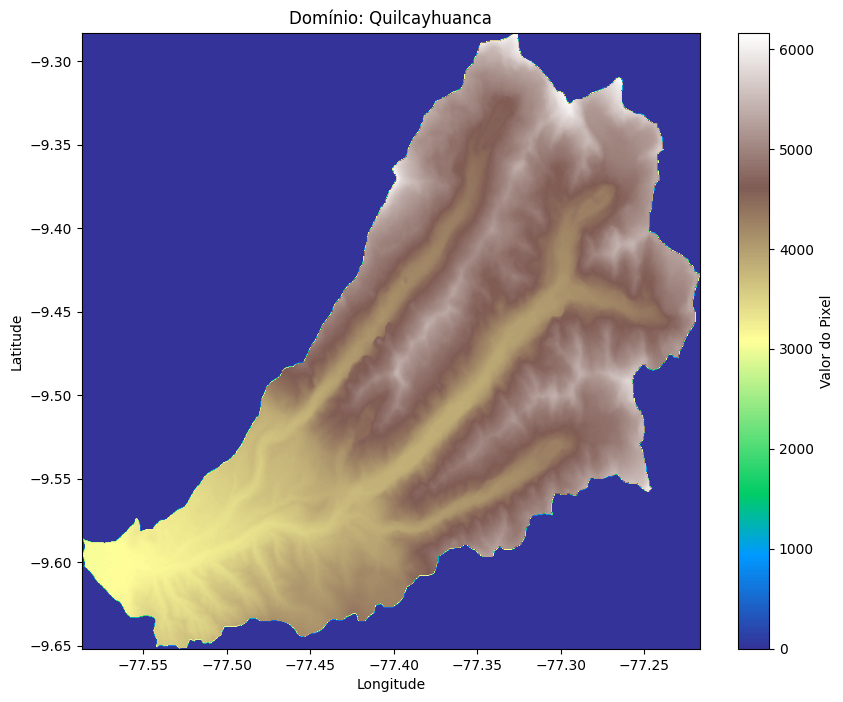

Domínio criado e salvo em: /home/matheus/Documentos/GitHub/LACRIO/Analises/Dominio/dados/dominios/Ranrahirca_dominio.tif


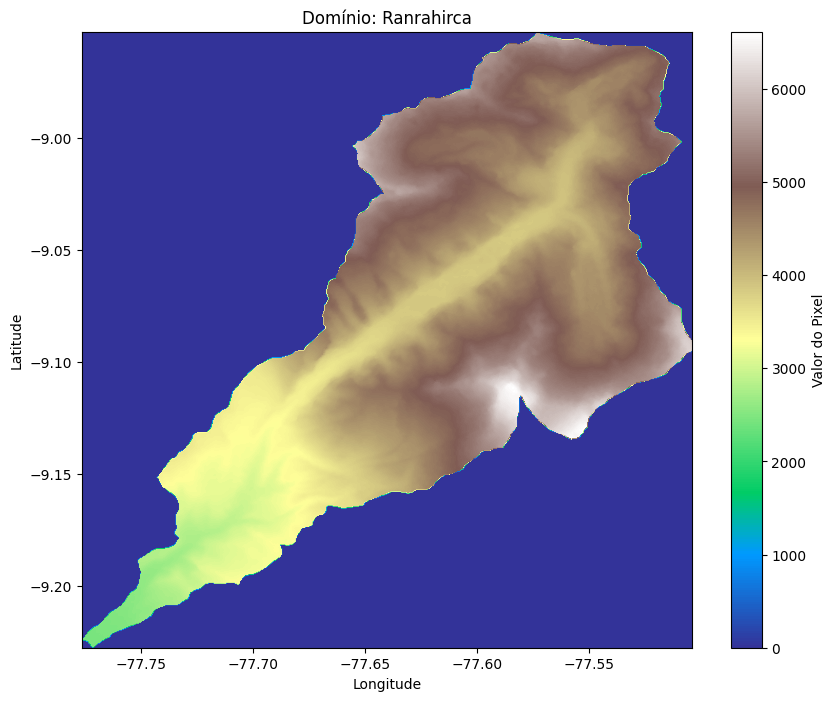

In [1]:

import os
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.plot import plotting_extent
import matplotlib.pyplot as plt

# Caminho da pasta onde estão os dados
base_path = "/home/matheus/Documentos/GitHub/LACRIO/Analises/Dominio/dados"

# Listar shapefiles e rasters
shapefiles = [f for f in os.listdir(base_path) if f.endswith(".shp")]
rasters = [f for f in os.listdir(base_path) if f.endswith(".tif")]

# Garantir que o diretório de saída exista
output_dir = os.path.join(base_path, "dominios")
os.makedirs(output_dir, exist_ok=True)

# Processar cada shapefile com correspondência parcial com raster
for shp_file in shapefiles:
    name_prefix = shp_file.replace(".shp", "").split("_")[0]  # usar apenas o início do nome (ex: Ranrahirca)
    matching_rasters = [r for r in rasters if name_prefix in r]
    if not matching_rasters:
        print(f"Nenhum raster correspondente encontrado para {shp_file}")
        continue
    
    raster_file = matching_rasters[0]
    
    # Caminhos completos
    shp_path = os.path.join(base_path, shp_file)
    raster_path = os.path.join(base_path, raster_file)

    # Leitura do shapefile
    gdf = gpd.read_file(shp_path)
    geoms = gdf.geometry.values

    # Leitura e recorte do raster
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, geoms, crop=True)
        out_meta = src.meta.copy()
        extent = plotting_extent(src, geoms)
    
    # Atualizar metadados
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })
    
    # Salvar raster recortado
    output_raster = os.path.join(output_dir, f"{name_prefix}_dominio.tif")
    with rasterio.open(output_raster, "w", **out_meta) as dest:
        dest.write(out_image)
    
    print(f"Domínio criado e salvo em: {output_raster}")
    
    # Plotar com coordenadas e barra de cores
    plt.figure(figsize=(10, 8))
    img = plt.imshow(out_image[0], cmap='terrain', extent=extent)
    plt.colorbar(img, label="Valor do Pixel")
    plt.title(f"Domínio: {name_prefix}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()
